<a href="https://colab.research.google.com/github/bellington90/intro-to-machine-learning/blob/main/01_NYC_IOS_Opportunity_Data_Reconnaissance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
project_path = "/content/drive/MyDrive/Industrial CRE Intelligence Lab/01 IOS Opportunity"

raw_data_path = f"{project_path}/Raw Data"
clean_data_path = f"{project_path}/Clean Data"
visuals_path = f"{project_path}/Visuals"
models_path = f"{project_path}/Models"
project_notes_path = f"{project_path}/Project Notes"

print("Project paths are set.")

Project paths are set.


In [ ]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
truck_routes_url = (
    "https://data.cityofnewyork.us/resource/"
    "jjja-shxy.geojson?$limit=50000"
)

truck_routes_raw = gpd.read_file(truck_routes_url)

In [ ]:
raw_truck_routes_file = (
    f"{raw_data_path}/NYC_Truck_Routes_RAW_2026-09-16.geojson"
)

truck_routes_raw.to_file(
    raw_truck_routes_file,
    driver="GeoJSON"
)

In [ ]:
import os

os.path.exists(raw_truck_routes_file)

True

In [ ]:
truck_routes_raw.shape

(32939, 23)

In [ ]:
truck_routes_raw.head()

,truckroute,coun_dist,thrutunl,objectid_1,thrubrg,ltdlocal,streetcode,localbrg,borocd,restrictio,...,boroname,thruexwy,routetype,localtunl,borocode,street,segmentid,nyc_reg,cong_dist,geometry
0,Y,14.0,,1.0,,,242820,,205.0,,...,Bronx,,Local,,2.0,JEROME AVENUE,0073071,"NYCDOT Traffic Rules, Section 4-13-(f)(2)",15.0,"MULTILINESTRING ((-73.90733 40.85382, -73.9055..."
1,Y,8.0,,2.0,,,226130,,201.0,,...,Bronx,,Local,,2.0,EAST 149 STREET,0077201,"NYCDOT Traffic Rules, Section 4-13-(f)(2)",15.0,"MULTILINESTRING ((-73.90342 40.81151, -73.9032..."
2,Y,15.0,,3.0,,,226910,,206.0,,...,Bronx,,Local,,2.0,EAST 175 STREET,0078397,"NYCDOT Traffic Rules, Section 4-13-(f)(2)",15.0,"MULTILINESTRING ((-73.90052 40.84512, -73.8993..."
3,Y,12.0,,4.0,,,253870,,212.0,,...,Bronx,Y,Through,,2.0,NEW ENGLAND THRUWAY,0119835,"NYCDOT Traffic Rules, Section 4-13-(f)(1)",16.0,"MULTILINESTRING ((-73.83434 40.87203, -73.8344..."
4,Y,12.0,,5.0,,,277150,,212.0,,...,Bronx,,Local,,2.0,WHITE PLAINS ROAD,0132595,"NYCDOT Traffic Rules, Section 4-13-(f)(2)",16.0,"MULTILINESTRING ((-73.86497 40.88067, -73.8649..."


In [ ]:
truck_routes_raw.columns.tolist()

['truckroute',
 'coun_dist',
 'thrutunl',
 'objectid_1',
 'thrubrg',
 'ltdlocal',
 'streetcode',
 'localbrg',
 'borocd',
 'restrictio',
 'shape_leng',
 'st_sen_dis',
 'assem_dist',
 'boroname',
 'thruexwy',
 'routetype',
 'localtunl',
 'borocode',
 'street',
 'segmentid',
 'nyc_reg',
 'cong_dist',
 'geometry']

In [ ]:
truck_routes_raw.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 32939 entries, 0 to 32938
Data columns (total 23 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   truckroute  32939 non-null  object  
 1   coun_dist   32939 non-null  object  
 2   thrutunl    32939 non-null  object  
 3   objectid_1  32939 non-null  object  
 4   thrubrg     32939 non-null  object  
 5   ltdlocal    32939 non-null  object  
 6   streetcode  32939 non-null  object  
 7   localbrg    32939 non-null  object  
 8   borocd      32939 non-null  object  
 9   restrictio  32939 non-null  object  
 10  shape_leng  32939 non-null  object  
 11  st_sen_dis  32939 non-null  object  
 12  assem_dist  32939 non-null  object  
 13  boroname    32939 non-null  object  
 14  thruexwy    32939 non-null  object  
 15  routetype   32939 non-null  object  
 16  localtunl   32939 non-null  object  
 17  borocode    32939 non-null  object  
 18  street      32939 non-null  object  
 

In [ ]:
truck_routes_raw.isna().sum().sort_values(ascending=False)

,0
truckroute,0
coun_dist,0
thrutunl,0
objectid_1,0
thrubrg,0
ltdlocal,0
streetcode,0
localbrg,0
borocd,0
restrictio,0


In [ ]:
truck_routes_raw.duplicated().sum()

np.int64(2)

In [ ]:
truck_routes_raw.geometry.isna().sum()

np.int64(0)

In [ ]:
(~truck_routes_raw.geometry.is_valid).sum()

np.int64(0)

In [ ]:
truck_routes_clean = truck_routes_raw.copy()

In [ ]:
text_columns = truck_routes_clean.select_dtypes(include="object").columns

for column in text_columns:
    cleaned = truck_routes_clean[column].str.strip()
    truck_routes_clean[column] = cleaned.mask(cleaned.eq(""), pd.NA)

In [ ]:
truck_routes_clean = truck_routes_clean.to_crs(epsg=2263)

In [ ]:
truck_routes_clean["segment_length_miles"] = (
    truck_routes_clean.geometry.length / 5280
)

In [ ]:
clean_truck_routes_file = (
    f"{clean_data_path}/NYC_Truck_Routes_CLEAN_2026-09-16.gpkg"
)

truck_routes_clean.to_file(
    clean_truck_routes_file,
    layer="truck_routes",
    driver="GPKG"
)

In [ ]:
os.path.exists(clean_truck_routes_file)

True

In [ ]:
truck_routes_clean.shape

(32939, 24)

In [ ]:
truck_routes_clean = truck_routes_clean.drop_duplicates().copy()

truck_routes_clean.shape

(32937, 24)

In [ ]:
truck_routes_clean.duplicated().sum()

np.int64(0)

In [ ]:
truck_routes_clean.to_file(
    clean_truck_routes_file,
    layer="truck_routes",
    driver="GPKG",
    mode="w"
)

In [ ]:
import requests

nyc_311_url = "https://data.cityofnewyork.us/resource/erm2-nwe9.json"

params = {
    "$select": "descriptor, count(*) as complaint_count",
    "$where": "complaint_type='Illegal Parking' AND lower(descriptor) like '%commercial%'",
    "$group": "descriptor",
    "$order": "complaint_count DESC"
}

response = requests.get(nyc_311_url, params=params)
commercial_parking_types = pd.DataFrame(response.json())

commercial_parking_types

,descriptor,complaint_count
0,Commercial Overnight Parking,238983
1,Overnight Commercial Storage,18846


In [ ]:
params_year = {
    "$select": "date_extract_y(created_date) as year, descriptor, count(*) as complaint_count",
    "$where": "complaint_type='Illegal Parking' AND lower(descriptor) like '%commercial%'",
    "$group": "year, descriptor",
    "$order": "year ASC"
}

response_year = requests.get(nyc_311_url, params=params_year)

commercial_parking_by_year = pd.DataFrame(response_year.json())

commercial_parking_by_year

,year,descriptor,complaint_count
0,2020,Commercial Overnight Parking,19820
1,2020,Overnight Commercial Storage,1684
2,2021,Commercial Overnight Parking,26998
3,2021,Overnight Commercial Storage,2063
4,2022,Commercial Overnight Parking,36898
5,2022,Overnight Commercial Storage,2454
6,2023,Commercial Overnight Parking,42134
7,2023,Overnight Commercial Storage,2708
8,2024,Commercial Overnight Parking,40577
9,2024,Overnight Commercial Storage,4107


In [ ]:
params_311 = {
    "$select": """
        unique_key,
        created_date,
        descriptor,
        incident_address,
        street_name,
        borough,
        incident_zip,
        latitude,
        longitude
    """,
    "$where": """
        complaint_type='Illegal Parking'
        AND lower(descriptor) like '%commercial%'
        AND created_date >= '2023-01-01T00:00:00'
        AND created_date < '2026-01-01T00:00:00'
    """,
    "$limit": 200000
}

response_311 = requests.get(nyc_311_url, params=params_311)

parking_311_raw = pd.DataFrame(response_311.json())

parking_311_raw.shape

(135908, 9)

In [ ]:
raw_311_file = (
    f"{raw_data_path}/NYC_311_Commercial_Parking_RAW_2023_2025.csv"
)

parking_311_raw.to_csv(
    raw_311_file,
    index=False
)

os.path.exists(raw_311_file)

True

In [ ]:
parking_311_raw.head()

,unique_key,created_date,descriptor,incident_address,street_name,borough,incident_zip,latitude,longitude
0,59450956,2023-11-16T00:49:19.000,Commercial Overnight Parking,31-09 106 STREET,106 STREET,QUEENS,11369,40.760662205464676,-73.86332087823054
1,58039357,2023-06-28T20:30:05.000,Overnight Commercial Storage,SAYRES AVENUE,SAYRES AVENUE,QUEENS,11433,NaN,NaN
2,58046808,2023-06-29T23:02:16.000,Commercial Overnight Parking,59 AVENUE,59 AVENUE,QUEENS,11365,40.740493425050175,-73.80739569510918
3,58036436,2023-06-28T19:18:35.000,Commercial Overnight Parking,78-50 81 STREET,81 STREET,QUEENS,11385,40.70403172974133,-73.86747285570526
4,58028532,2023-06-27T02:42:44.000,Commercial Overnight Parking,LINDEN BOULEVARD,LINDEN BOULEVARD,BROOKLYN,11208,40.665598831565255,-73.87430783340554


In [ ]:
parking_311_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135908 entries, 0 to 135907
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   unique_key        135908 non-null  object
 1   created_date      135908 non-null  object
 2   descriptor        135908 non-null  object
 3   incident_address  135854 non-null  object
 4   street_name       135854 non-null  object
 5   borough           135908 non-null  object
 6   incident_zip      135846 non-null  object
 7   latitude          134302 non-null  object
 8   longitude         134302 non-null  object
dtypes: object(9)
memory usage: 9.3+ MB


In [ ]:
parking_311_raw.isna().sum().sort_values(ascending=False)

,0
latitude,1606
longitude,1606
incident_zip,62
incident_address,54
street_name,54
unique_key,0
descriptor,0
created_date,0
borough,0


In [ ]:
parking_311_raw.duplicated().sum()

np.int64(0)

In [ ]:
parking_311_raw[["latitude", "longitude"]].isna().sum()

,0
latitude,1606
longitude,1606


In [ ]:
parking_311_clean = parking_311_raw.copy()

In [ ]:
parking_311_clean["created_date"] = pd.to_datetime(
    parking_311_clean["created_date"],
    errors="coerce"
)

parking_311_clean["latitude"] = pd.to_numeric(
    parking_311_clean["latitude"],
    errors="coerce"
)

parking_311_clean["longitude"] = pd.to_numeric(
    parking_311_clean["longitude"],
    errors="coerce"
)

In [ ]:
text_columns_311 = [
    "descriptor",
    "incident_address",
    "street_name",
    "borough",
    "incident_zip"
]

for column in text_columns_311:
    parking_311_clean[column] = (
        parking_311_clean[column]
        .str.strip()
    )

In [ ]:
parking_311_clean = parking_311_clean.dropna(
    subset=["latitude", "longitude"]
).copy()

parking_311_clean.shape

(134302, 9)

In [ ]:
parking_311_clean = gpd.GeoDataFrame(
    parking_311_clean,
    geometry=gpd.points_from_xy(
        parking_311_clean["longitude"],
        parking_311_clean["latitude"]
    ),
    crs="EPSG:4326"
)

In [ ]:
parking_311_clean = parking_311_clean.to_crs(epsg=2263)

In [ ]:
clean_311_file = (
    f"{clean_data_path}/NYC_311_Commercial_Parking_CLEAN_2023_2025.gpkg"
)

parking_311_clean.to_file(
    clean_311_file,
    layer="commercial_parking_311",
    driver="GPKG"
)

In [ ]:
os.path.exists(clean_311_file)

True

In [ ]:
parking_311_clean.shape

(134302, 10)

In [ ]:
truck_routes_for_join = truck_routes_clean[
    [
        "segmentid",
        "street",
        "boroname",
        "routetype",
        "segment_length_miles",
        "geometry"
    ]
].copy()

In [ ]:
parking_with_routes = gpd.sjoin_nearest(
    parking_311_clean,
    truck_routes_for_join,
    how="left",
    distance_col="distance_to_route_ft"
)

In [ ]:
parking_with_routes.shape

(149409, 17)

In [ ]:
parking_with_routes.head()

,unique_key,created_date,descriptor,incident_address,street_name,borough,incident_zip,latitude,longitude,geometry,index_right,segmentid,street,boroname,routetype,segment_length_miles,distance_to_route_ft
0,59450956,2023-11-16 00:49:19,Commercial Overnight Parking,31-09 106 STREET,106 STREET,QUEENS,11369,40.760662,-73.863321,POINT (1022114 216436.014),22507,0156115,ASTORIA BOULEVARD,Queens,Through,0.052689,76.343530
2,58046808,2023-06-29 23:02:16,Commercial Overnight Parking,59 AVENUE,59 AVENUE,QUEENS,11365,40.740493,-73.807396,POINT (1037623 209117.014),22299,0090702,LONG ISLAND EXPWY ET 24 WB,Queens,Through,0.058402,647.638785
3,58036436,2023-06-28 19:18:35,Commercial Overnight Parking,78-50 81 STREET,81 STREET,QUEENS,11385,40.704032,-73.867473,POINT (1020995 195802.014),18707,0052270,MYRTLE AVENUE,Queens,Through,0.052615,361.731052
4,58028532,2023-06-27 02:42:44,Commercial Overnight Parking,LINDEN BOULEVARD,LINDEN BOULEVARD,BROOKLYN,11208,40.665599,-73.874308,POINT (1019120 181797.014),8401,0157783,LINDEN BOULEVARD,Brooklyn,Local,0.041444,22.310325
5,58039599,2023-06-28 21:01:46,Commercial Overnight Parking,99 AVENUE,99 AVENUE,QUEENS,11423,40.712006,-73.758104,POINT (1051311 198772.014),22927,0148834,JAMAICA AVENUE,Queens,Local,0.059525,527.295702


In [ ]:
parking_with_routes["distance_to_route_ft"].describe(
    percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
)

,distance_to_route_ft
count,149409.000000
mean,920.684465
std,997.620812
min,0.000100
50%,634.715660
75%,1275.239811
90%,2142.829626
95%,2942.290813
99%,4922.769182
max,7355.174952


In [ ]:
parking_with_routes["unique_key"].nunique()

134302

In [ ]:
match_counts = parking_with_routes.groupby("unique_key").size()

print("Complaints matched more than once:", (match_counts > 1).sum())
print("Maximum matches for one complaint:", match_counts.max())

Complaints matched more than once: 13855
Maximum matches for one complaint: 4


In [ ]:
thresholds = [250, 500, 750, 1000, 1320, 1500, 2000]

for feet in thresholds:
    complaint_count = parking_with_routes.loc[
        parking_with_routes["distance_to_route_ft"] <= feet,
        "unique_key"
    ].nunique()

    percent = complaint_count / parking_311_clean["unique_key"].nunique() * 100

    print(feet, "feet:", complaint_count, "complaints -", round(percent, 1), "%")

250 feet: 38280 complaints - 28.5 %
500 feet: 61381 complaints - 45.7 %
750 feet: 78951 complaints - 58.8 %
1000 feet: 93518 complaints - 69.6 %
1320 feet: 106477 complaints - 79.3 %
1500 feet: 111912 complaints - 83.3 %
2000 feet: 121660 complaints - 90.6 %


In [ ]:
truck_routes_clean = truck_routes_clean.reset_index(drop=True).copy()

truck_routes_clean["route_id"] = np.arange(
    1,
    len(truck_routes_clean) + 1
)

In [ ]:
truck_routes_for_join = truck_routes_clean[
    [
        "route_id",
        "segmentid",
        "street",
        "boroname",
        "routetype",
        "segment_length_miles",
        "geometry"
    ]
].copy()

In [ ]:
parking_near_routes = gpd.sjoin_nearest(
    parking_311_clean,
    truck_routes_for_join,
    how="inner",
    max_distance=1000,
    distance_col="distance_to_route_ft"
)

In [ ]:
parking_near_routes["unique_key"].nunique()

93518

In [ ]:
parking_near_routes["match_count"] = (
    parking_near_routes
    .groupby("unique_key")["unique_key"]
    .transform("size")
)

parking_near_routes["complaint_weight"] = (
    1 / parking_near_routes["match_count"]
)

In [ ]:
parking_near_routes["complaint_weight"].sum()

np.float64(93518.0)

In [ ]:
segment_pressure = (
    parking_near_routes
    .groupby("route_id", as_index=False)
    .agg(
        weighted_complaints=("complaint_weight", "sum"),
        average_distance_ft=("distance_to_route_ft", "mean")
    )
)

In [ ]:
truck_routes_model = truck_routes_clean.merge(
    segment_pressure,
    on="route_id",
    how="left"
)

truck_routes_model["weighted_complaints"] = (
    truck_routes_model["weighted_complaints"].fillna(0)
)

In [ ]:
truck_routes_model.shape

(32937, 27)

In [ ]:
truck_routes_model["weighted_complaints"].describe()

,weighted_complaints
count,32937.000000
mean,2.839299
std,22.886456
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,2749.000000


In [ ]:
(truck_routes_model["segment_length_miles"] <= 0).sum()

np.int64(0)

In [ ]:
truck_routes_model["complaints_per_mile"] = (
    truck_routes_model["weighted_complaints"]
    / truck_routes_model["segment_length_miles"]
)

In [ ]:
truck_routes_model["complaints_per_mile"].describe(
    percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
)

,complaints_per_mile
count,32937.000000
mean,69.357941
std,668.246151
min,0.000000
50%,0.000000
75%,25.260083
90%,144.052386
95%,298.204458
99%,976.007393
max,75051.515331


In [ ]:
truck_routes_model[
    [
        "street",
        "boroname",
        "routetype",
        "segment_length_miles",
        "weighted_complaints",
        "complaints_per_mile"
    ]
].sort_values(
    "complaints_per_mile",
    ascending=False
).head(20)

,street,boroname,routetype,segment_length_miles,weighted_complaints,complaints_per_mile
8795,PROSPECT STREET,Brooklyn,Local,0.012991,975.0,75051.515331
11379,BROOKLYN QUEENS EXPRESSWAY,Brooklyn,Through,0.015109,818.0,54141.438995
14033,BROADWAY,Manhattan,Local,0.052778,2749.0,52086.327378
20464,HORACE HARDING EXPRESSWAY,Queens,Through,0.098905,2081.0,21040.423221
9027,FLATBUSH AVENUE,Brooklyn,Through,0.006026,81.0,13441.988810
21146,NORTHERN BOULEVARD,Queens,Through,0.036416,477.0,13098.477610
7575,MANHATTAN BRIDGE APPROACH,Brooklyn,Through,0.009009,118.0,13098.059879
12411,OLD FULTON STREET,Brooklyn,Local,0.005299,58.5,11040.484173
27838,PARSONS BOULEVARD,Queens,Local,0.005304,57.0,10747.194733
11659,FLUSHING AVENUE,Brooklyn,Local,0.008641,85.0,9836.566218


In [ ]:
truck_routes_model["segment_length_miles"].describe(
    percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

,segment_length_miles
count,32937.000000
mean,0.040647
std,0.037761
min,0.000813
1%,0.002744
5%,0.004163
10%,0.005767
25%,0.013365
50%,0.034170
75%,0.051662


In [ ]:
truck_routes_model["weighted_complaints"].describe(
    percentiles=[0.50, 0.75, 0.80, 0.90, 0.95, 0.99]
)

,weighted_complaints
count,32937.000000
mean,2.839299
std,22.886456
min,0.000000
50%,0.000000
75%,1.000000
80%,2.000000
90%,6.000000
95%,13.000000
99%,43.320000


In [ ]:
zero_pressure_pct = (
    truck_routes_model["weighted_complaints"].eq(0).mean() * 100
)

zero_pressure_pct

np.float64(68.69781704466102)

In [ ]:
for percentile in [0.80, 0.90, 0.95]:
    cutoff = truck_routes_model["weighted_complaints"].quantile(percentile)

    high_pressure_count = (
        truck_routes_model["weighted_complaints"] >= cutoff
    ).sum()

    high_pressure_pct = (
        high_pressure_count / len(truck_routes_model) * 100
    )

    print(
        f"{int(percentile * 100)}th percentile:",
        f"cutoff = {cutoff}",
        f"| segments = {high_pressure_count}",
        f"| {high_pressure_pct:.1f}% of routes"
    )

80th percentile: cutoff = 2.0 | segments = 7132 | 21.7% of routes
90th percentile: cutoff = 6.0 | segments = 3466 | 10.5% of routes
95th percentile: cutoff = 13.0 | segments = 1729 | 5.2% of routes


In [ ]:
truck_routes_model["high_parking_pressure"] = (
    truck_routes_model["weighted_complaints"] >= 6
).astype(int)

In [ ]:
truck_routes_model["high_parking_pressure"].value_counts()

,count
high_parking_pressure,
0,29471
1,3466


In [ ]:
truck_routes_model["high_parking_pressure"].value_counts(normalize=True) * 100

,proportion
high_parking_pressure,
0,89.47688
1,10.52312


In [ ]:
import os

os.listdir(raw_data_path)

['NYC_Truck_Routes_RAW_2026-09-16.geojson',
 'NYC_311_Commercial_Parking_RAW_2023_2025.csv',
 'IBZ Shapefiles.zip']

In [ ]:
import zipfile

ibz_zip_path = f"{raw_data_path}/IBZ Shapefiles.zip"

with zipfile.ZipFile(ibz_zip_path, "r") as z:
    ibz_files = z.namelist()

ibz_files

['IBZ.shx',
 'IBZ.cpg',
 'IBZ.dbf',
 'IBZ.prj',
 'IBZ.sbn',
 'IBZ.sbx',
 'IBZ.shp',
 'IBZ.shp.xml',
 'IBZ Shapefiles Disclaimer.docx']

In [ ]:
ibz_extract_path = "/content/ibz_shapefile"

with zipfile.ZipFile(ibz_zip_path, "r") as z:
    z.extractall(ibz_extract_path)

In [ ]:
ibz_raw = gpd.read_file(f"{ibz_extract_path}/IBZ.shp")

In [ ]:
ibz_raw.shape

(21, 7)

In [ ]:
ibz_raw.columns.tolist()

['OBJECTID',
 'NAME',
 'BORONAME',
 'BOROCODE',
 'Shape_Leng',
 'Shape_Area',
 'geometry']

In [ ]:
ibz_raw.head()

,OBJECTID,NAME,BORONAME,BOROCODE,Shape_Leng,Shape_Area,geometry
0,1,Zerega,Bronx,2,39571.205154,1.190033e+07,"MULTIPOLYGON (((1027840.763 240864.707, 102784..."
1,2,Ridgewood,Queens,4,15978.825743,1.895672e+06,"MULTIPOLYGON (((1011002.227 192636.995, 101098..."
2,3,Rossville,Staten island,5,33665.853078,2.515884e+07,"POLYGON ((924909.463 141810.594, 924912.798 14..."
3,4,Astoria,Queens,4,68045.262556,6.377269e+07,"POLYGON ((1022118.575 228105.25, 1020551.29 22..."
4,5,Jamaica,Queens,4,48178.156167,1.566261e+07,"MULTIPOLYGON (((1040457.783 193639.166, 104049..."


In [ ]:
ibz_raw.crs

<Projected CRS: EPSG:2263>
Name: NAD83 / New York Long Island (ftUS)
Axis Info [cartesian]:
- X[east]: Easting (US survey foot)
- Y[north]: Northing (US survey foot)
Area of Use:
- name: United States (USA) - New York - counties of Bronx; Kings; Nassau; New York; Queens; Richmond; Suffolk.
- bounds: (-74.26, 40.47, -71.8, 41.3)
Coordinate Operation:
- name: SPCS83 New York Long Island zone (US survey foot)
- method: Lambert Conic Conformal (2SP)
Datum: North American Datum 1983
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [ ]:
ibz_raw["NAME"].sort_values().tolist()

['Astoria',
 'Bathgate',
 'Brooklyn Navy Yards',
 'East New York',
 'Eastchester',
 'Flatlands/Fairfield',
 'Greenpoint/Williamsburg',
 'Hunts Point',
 'JFK',
 'Jamaica',
 'Long Island City',
 'Maspeth',
 'North Brooklyn',
 'Port Morris',
 'Ridgewood',
 'Rossville',
 'Southwest Brooklyn',
 'Staten Island North Shore',
 'Staten Island West Shore',
 'Woodside',
 'Zerega']

In [ ]:
ibz_raw.isna().sum()

,0
OBJECTID,0
NAME,0
BORONAME,0
BOROCODE,0
Shape_Leng,0
Shape_Area,0
geometry,0


In [ ]:
ibz_raw.duplicated().sum()

np.int64(0)

In [ ]:
(~ibz_raw.geometry.is_valid).sum()

np.int64(3)

In [ ]:
ibz_clean = ibz_raw.copy()

In [ ]:
ibz_clean = ibz_clean[
    ["NAME", "BORONAME", "geometry"]
].copy()

ibz_clean = ibz_clean.rename(
    columns={
        "NAME": "ibz_name",
        "BORONAME": "ibz_borough"
    }
)

In [ ]:
clean_ibz_file = (
    f"{clean_data_path}/NYC_IBZ_Boundaries_CLEAN.gpkg"
)

ibz_clean.to_file(
    clean_ibz_file,
    layer="ibz_boundaries",
    driver="GPKG"
)

In [ ]:
routes_with_ibz = gpd.sjoin_nearest(
    truck_routes_model,
    ibz_clean,
    how="left",
    distance_col="distance_to_ibz_ft"
)

In [ ]:
routes_with_ibz["inside_or_touching_ibz"] = (
    routes_with_ibz["distance_to_ibz_ft"] == 0
).astype(int)

In [ ]:
routes_with_ibz["near_ibz_1000ft"] = (
    routes_with_ibz["distance_to_ibz_ft"] <= 1000
).astype(int)

In [ ]:
ibz_clean["geometry"] = ibz_clean.geometry.make_valid()

(~ibz_clean.geometry.is_valid).sum()

np.int64(0)

In [ ]:
ibz_clean.to_file(
    clean_ibz_file,
    layer="ibz_boundaries",
    driver="GPKG",
    mode="w"
)

In [ ]:
routes_with_ibz = gpd.sjoin_nearest(
    truck_routes_model,
    ibz_clean,
    how="left",
    distance_col="distance_to_ibz_ft"
)

In [ ]:
routes_with_ibz["inside_or_touching_ibz"] = (
    routes_with_ibz["distance_to_ibz_ft"] == 0
).astype(int)

routes_with_ibz["near_ibz_1000ft"] = (
    routes_with_ibz["distance_to_ibz_ft"] <= 1000
).astype(int)

In [ ]:
routes_with_ibz.shape

(32952, 35)

In [ ]:
routes_with_ibz["route_id"].nunique()

32937

In [ ]:
ibz_match_counts = routes_with_ibz.groupby("route_id").size()

(ibz_match_counts > 1).sum()

np.int64(15)

In [ ]:
ibz_summary = (
    routes_with_ibz
    .groupby("route_id", as_index=False)
    .agg(
        nearest_ibz=("ibz_name", lambda x: " | ".join(sorted(set(x.dropna())))),
        distance_to_ibz_ft=("distance_to_ibz_ft", "min"),
        inside_or_touching_ibz=("inside_or_touching_ibz", "max"),
        near_ibz_1000ft=("near_ibz_1000ft", "max")
    )
)

In [ ]:
truck_routes_model = truck_routes_model.merge(
    ibz_summary,
    on="route_id",
    how="left"
)

In [ ]:
truck_routes_model.shape

(32937, 33)

In [ ]:
truck_routes_model["inside_or_touching_ibz"].value_counts()

,count
inside_or_touching_ibz,
0,30149
1,2788


In [ ]:
truck_routes_model["near_ibz_1000ft"].value_counts()

,count
near_ibz_1000ft,
0,25387
1,7550


In [ ]:
pd.crosstab(
    truck_routes_model["near_ibz_1000ft"],
    truck_routes_model["high_parking_pressure"],
    normalize="index"
) * 100

high_parking_pressure,0,1
near_ibz_1000ft,,
0,88.399575,11.600425
1,93.099338,6.900662


In [ ]:
checkpoint_file = (
    f"{clean_data_path}/NYC_IOS_Model_Base_CHECKPOINT_2026-09-16.gpkg"
)

truck_routes_model.to_file(
    checkpoint_file,
    layer="ios_model_base",
    driver="GPKG",
    mode="w"
)

os.path.exists(checkpoint_file)

True

In [ ]:
matches_file = (
    f"{clean_data_path}/NYC_311_TruckRoute_Matches_1000ft_CHECKPOINT_2026-09-16.gpkg"
)

parking_near_routes.to_file(
    matches_file,
    layer="parking_route_matches",
    driver="GPKG",
    mode="w"
)

os.path.exists(matches_file)

True

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import geopandas as gpd

In [3]:
checkpoint_file = (
    "/content/drive/MyDrive/Industrial CRE Intelligence Lab/"
    "01 IOS Opportunity/Clean Data/"
    "NYC_IOS_Model_Base_CHECKPOINT_2026-09-16.gpkg"
)

truck_routes_model = gpd.read_file(
    checkpoint_file,
    layer="ios_model_base"
)

In [4]:
truck_routes_model.shape

(32937, 33)

# Capstone Modeling

## Research Question

Can characteristics of NYC truck-route segments and their proximity to
industrial areas help predict whether a route segment experiences unusually
high commercial-vehicle parking pressure?

Target:
- 0 = not high parking pressure
- 1 = high parking pressure

In [5]:
model_columns = [
    "boroname",
    "routetype",
    "segment_length_miles",
    "distance_to_ibz_ft",
    "inside_or_touching_ibz",
    "near_ibz_1000ft",
    "high_parking_pressure"
]

truck_routes_model[model_columns].head(10)

,boroname,routetype,segment_length_miles,distance_to_ibz_ft,inside_or_touching_ibz,near_ibz_1000ft,high_parking_pressure
0,Bronx,Local,0.164397,3015.286371,0,0,0
1,Bronx,Local,0.055547,0.000000,1,1,1
2,Bronx,Local,0.066989,0.000000,1,1,0
3,Bronx,Through,0.119759,3327.065860,0,0,0
4,Bronx,Local,0.068202,8471.531561,0,0,1
5,Bronx,Local,0.049548,5938.313261,0,0,1
6,Bronx,Local,0.067559,5654.311300,0,0,0
7,Bronx,Local,0.004434,7526.691393,0,0,0
8,Bronx,Local,0.003284,6998.394697,0,0,0
9,Bronx,Local,0.050345,5337.200807,0,0,1


## Model Training and Comparison

The dataset was split into training and testing data. Three classification
algorithms were trained on the same features and evaluated on the same test set:

1. Logistic Regression
2. Decision Tree
3. Random Forest

Because high-pressure routes represent only about 10.5% of the dataset,
precision, recall, and F1 score for the high-pressure class are considered
alongside overall accuracy.

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# X = clues
features = [
    "boroname",
    "routetype",
    "segment_length_miles",
    "distance_to_ibz_ft",
    "inside_or_touching_ibz",
    "near_ibz_1000ft"
]

X = truck_routes_model[features].copy()

# y = answer
y = truck_routes_model["high_parking_pressure"].copy()

# Tell Python which clues are words and which are numbers
categorical_features = ["boroname", "routetype"]

numeric_features = [
    "segment_length_miles",
    "distance_to_ibz_ft",
    "inside_or_touching_ibz",
    "near_ibz_1000ft"
]

# Convert words to machine-readable numbers and scale numeric values
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", StandardScaler(), numeric_features)
    ]
)

# 80% study pile / 20% final exam pile
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training examples:", len(X_train))
print("Testing examples:", len(X_test))

# Three different ways of answering the SAME question
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=8,
        random_state=42,
        class_weight="balanced"
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    )
}

results = []
fitted_models = {}

for name, model in models.items():

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    # STUDY
    pipeline.fit(X_train, y_train)

    # TAKE THE EXAM
    y_pred = pipeline.predict(X_test)

    fitted_models[name] = pipeline

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision - High Pressure": precision_score(y_test, y_pred, zero_division=0),
        "Recall - High Pressure": recall_score(y_test, y_pred, zero_division=0),
        "F1 - High Pressure": f1_score(y_test, y_pred, zero_division=0)
    })

results_df = pd.DataFrame(results).sort_values(
    "F1 - High Pressure",
    ascending=False
)

results_df

Training examples: 26349
Testing examples: 6588


,Model,Accuracy,Precision - High Pressure,Recall - High Pressure,F1 - High Pressure
1,Decision Tree,0.702186,0.227565,0.764791,0.350761
0,Logistic Regression,0.711597,0.224051,0.707071,0.340278
2,Random Forest,0.884032,0.374558,0.152958,0.217213


## Model Results

Three classification models were evaluated using the same training and testing data.

The Random Forest produced the highest overall accuracy at 88.4%, but identified
only 15.3% of the actual high-parking-pressure routes.

The Decision Tree had lower overall accuracy at 70.2%, but identified 76.5% of
the actual high-pressure routes and produced the highest F1 score for the
high-pressure class.

Because only about 10.5% of route segments are classified as high pressure,
overall accuracy alone can be misleading. For this project's use case as an
opportunity-screening tool, recall and F1 score for the high-pressure class are
especially important.

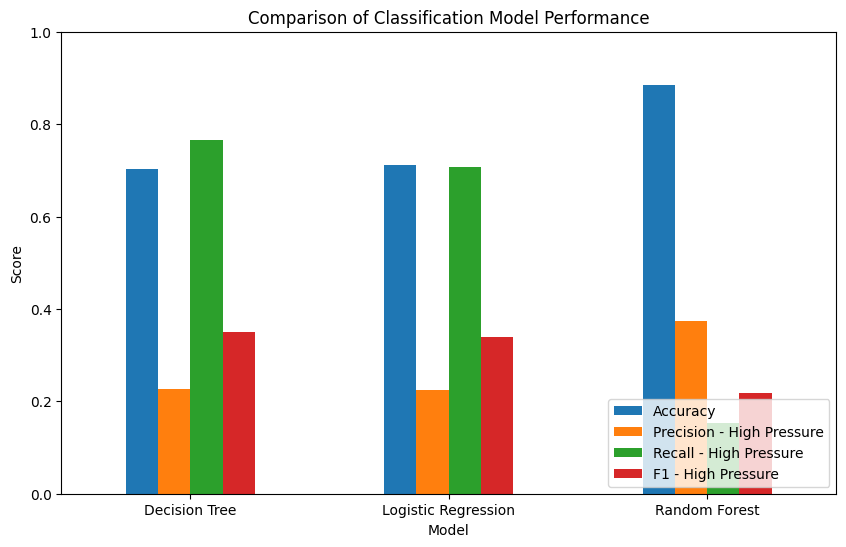

In [7]:
import matplotlib.pyplot as plt

results_chart = results_df.set_index("Model")[
    [
        "Accuracy",
        "Precision - High Pressure",
        "Recall - High Pressure",
        "F1 - High Pressure"
    ]
]

results_chart.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Comparison of Classification Model Performance")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.show()

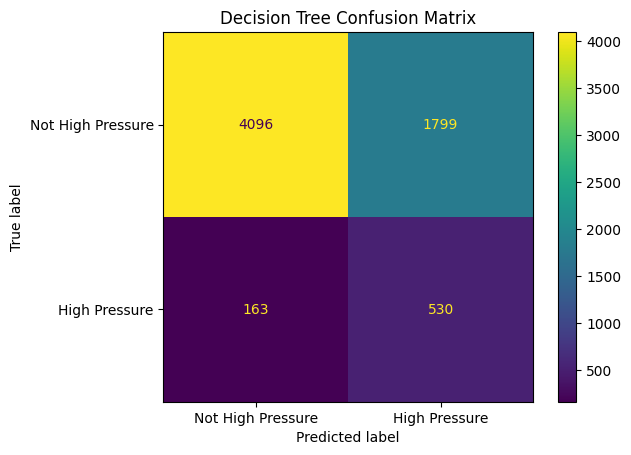

In [8]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

decision_tree_model = fitted_models["Decision Tree"]

y_pred_dt = decision_tree_model.predict(X_test)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_dt,
    display_labels=["Not High Pressure", "High Pressure"]
)

plt.title("Decision Tree Confusion Matrix")
plt.show()

## Conclusion and Limitations

The analysis demonstrates that route characteristics and proximity to industrial
geography can be used to build a predictive classification model of commercial
parking pressure, but the current feature set does not provide highly precise
identification of high-pressure locations.

Among the three models tested, the Decision Tree was the most useful for the
screening objective because it identified the largest share of actual
high-pressure routes while also producing the highest F1 score for that class.

The relatively low precision suggests that parking pressure is influenced by
factors not yet included in the model. Future versions could incorporate zoning,
commercial vehicle parking enforcement, truck-parking supply, land use,
population density, and parcel-level industrial real estate characteristics.

This capstone represents the first machine-learning layer of a broader Industrial
CRE intelligence project focused on identifying potential unmet freight and
Industrial Outdoor Storage demand.

# Final Interpretation and Conclusion

## Project Summary

This project explored whether characteristics of New York City truck-route segments and their proximity to industrial areas could help predict unusually high commercial-vehicle parking pressure.

The project was inspired by my interest in Industrial Commercial Real Estate, particularly Industrial Outdoor Storage (IOS). I wanted to explore whether public data could be used to identify patterns of commercial-vehicle parking pressure that could eventually become one signal within a broader industrial real estate opportunity-screening framework.

To build the analysis, I combined three public datasets:

- NYC Truck Routes
- NYC 311 commercial overnight parking complaints
- NYC Industrial Business Zone (IBZ) boundaries

After cleaning and geographically integrating the data, the final modeling dataset contained 32,937 truck-route segments.

## Features and Target

The model used six predictor features:

- Borough
- Truck route type
- Segment length
- Distance to the nearest Industrial Business Zone
- Whether the route touches an IBZ
- Whether the route is within 1,000 feet of an IBZ

The target variable was `high_parking_pressure`.

- 0 = not unusually high parking pressure
- 1 = unusually high parking pressure

Approximately 10.5% of the route segments were classified as high parking pressure, meaning the dataset was imbalanced.

## Modeling Approach

I compared three supervised classification algorithms using the same training and testing data:

1. Logistic Regression
2. Decision Tree
3. Random Forest

The data were split into 26,349 training examples and 6,588 testing examples.

Because the high-pressure class represented only a small portion of the dataset, I evaluated the models using accuracy, precision, recall, and F1 score rather than relying on accuracy alone.

## Model Results

The Random Forest achieved the highest overall accuracy at approximately 88.4%. However, its recall for the high-parking-pressure class was only approximately 15.3%.

This means that although Random Forest classified many routes correctly overall, it missed most of the routes that actually experienced high parking pressure.

Logistic Regression achieved approximately 71.2% accuracy and approximately 70.7% recall for the high-pressure class.

The Decision Tree achieved approximately 70.2% overall accuracy and approximately 76.5% recall for the high-pressure class. It also produced the highest F1 score for the high-pressure class among the three models.

For this project, I considered the Decision Tree the most useful of the three models for a screening use case because it identified the largest proportion of actual high-pressure routes.

However, its precision was only approximately 22.8%, which means it also produced many false positives.

## Interpretation

One of the most important findings from this project was that overall accuracy can be misleading when working with an imbalanced target.

Because almost 90% of the routes were not classified as high pressure, a model could achieve relatively high accuracy simply by predicting the majority class most of the time.

For an opportunity-screening use case, I was more interested in whether the model could actually identify high-pressure routes. For that reason, recall and F1 score were particularly important in interpreting the results.

The Decision Tree behaved more like a broad screening model: it identified many of the true high-pressure locations, but it also flagged many locations that were not actually high pressure.

## Limitations

The results suggest that truck-route characteristics and proximity to Industrial Business Zones alone are not sufficient to precisely explain commercial-vehicle parking pressure.

The model does not establish that parking pressure is caused by a lack of Industrial Outdoor Storage, nor should the current model be used as a final real estate investment or site-selection tool.

Additional variables would likely be needed to improve the analysis.

## Future Development

Future versions of this project could incorporate:

- zoning and land use
- commercial vehicle parking enforcement
- existing truck-parking and storage supply
- freight-generating businesses
- population density
- parcel-level industrial property characteristics
- vacant or underutilized industrial land
- redevelopment or acquisition opportunities

The long-term goal would be to evolve this initial machine-learning model into a broader Industrial CRE intelligence and IOS opportunity-screening tool.

## Conclusion

This capstone demonstrates the process of taking multiple real-world public datasets, cleaning and geographically integrating them, engineering new features, defining a predictive target, training multiple classification models, and critically interpreting the results.

The project also showed that the model with the highest overall accuracy is not automatically the most useful model for the business problem being studied.

This analysis represents the first machine-learning component of a larger Industrial CRE Intelligence project that I plan to continue developing beyond this course.